# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  
**Модуль:** Введение в Data Science и EDA  
**Датасет:** Titanic 
**Выполнил:** Володина Александра Александровна 
**Группа:** ПКТб-23-1  
**Преподаватель:** Спирин Игорь Сергеевич  
**Ссылка на репозиторий:** https://github.com/VolodinaAlexandra/ml-course-volodina.git
**Путь:** `module-1-titanic/notebook.ipynb`  
**Дата:** 2026-09-27

## Введение

**Задача:** предсказать бинарную целевую переменную `Survived`: 0 — пассажир не выжил, 1 — выжил.

**ML-проект** включает загрузку данных, EDA, предобработку, feature engineering, обучение, оценку и интерпретацию моделей.

Это **классификация**, поскольку результатом является один из двух дискретных классов, а не непрерывное число.

Из-за дисбаланса классов (61,6% / 38,4%) оцениваются не только Accuracy, но и Precision, Recall, F1 и ROC-AUC. Основной ориентир сравнения — ROC-AUC. Она оценивает качество ранжирования пассажиров по вероятности выживания независимо от одного фиксированного порога.

### Цели
1. Провести полный EDA Titanic.
2. Обучить Logistic Regression и Decision Tree и получить информативное сравнение.
3. Реализовать функцию предсказания нового пассажира.

## Теоретическая часть

### EDA
EDA — разведочный анализ данных. Он помогает понять структуру, типы признаков, распределения, пропуски, выбросы и связи между переменными. Обычно используются таблицы, статистики и графики. EDA позволяет обнаружить проблемы до обучения модели.

### Пропуски
Пропуски возникают, когда значение не было записано или неизвестно. Их можно удалять, заменять статистиками или восстанавливать модельными методами. Для числовых данных медиана часто устойчивее среднего к выбросам, а для категорий удобно использовать моду.

### Кодирование
Моделям нужны числовые признаки. Бинарные категории можно представить 0/1, а номинальные категории — One-Hot Encoding. One-Hot не создаёт искусственного порядка между категориями.

### Масштабирование
`StandardScaler` приводит признаки примерно к нулевому среднему и единичному стандартному отклонению. Оно особенно полезно для Logistic Regression. Для дерева решений масштабирование не требуется.

### Feature Engineering
Feature Engineering — создание новых признаков из исходных. Например, размер семьи может объединить информацию о родственниках пассажира и дать модели более удобный сигнал.

### Метрики
$$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$

$$Precision = \frac{TP}{TP+FP},\qquad Recall = \frac{TP}{TP+FN}$$

$$F1 = 2\cdot\frac{Precision\cdot Recall}{Precision+Recall}$$

ROC-AUC показывает способность модели разделять классы по различным порогам; 0,5 соответствует случайному ранжированию, значение ближе к 1 — более качественному разделению.

| Этап | Что выполняется |
|---|---|
| Загрузка | `train.csv`, `test.csv` |
| EDA | структура, статистики, пропуски, графики |
| Предобработка | заполнение пропусков, удаление Cabin |
| Feature Engineering | Family_Size, Is_Alone, Age_Group |
| Модели | Logistic Regression, Decision Tree |
| Оценка | Accuracy, Precision, Recall, F1, ROC-AUC |
| Интерпретация | коэффициенты и важность признаков |

## Описание данных

**Источник:** https://www.kaggle.com/c/titanic

**Структура:**

- Всего примеров в train: 891
- Всего примеров в test: 418
- Признаков: 11 (+ целевая `Survived`)
- Числовых признаков: 6
- Категориальных признаков: 5

**Описание столбцов:**

| Столбец | Тип | Описание | Пропуски |
|---------|-----|----------|----------|
| PassengerId | int64 | ID пассажира | 0% |
| Survived | int64 (0/1) | Целевая: выжил или нет | 0% |
| Pclass | int64 (1/2/3) | Класс билета | 0% |
| Name | object | Имя пассажира | 0% |
| Sex | object | Пол пассажира | 0% |
| Age | float64 | Возраст пассажира | 19.9% |
| SibSp | int64 | Количество братьев, сестёр и супругов на борту | 0% |
| Parch | int64 | Количество родителей и детей на борту | 0% |
| Ticket | object | Номер билета | 0% |
| Fare | float64 | Стоимость билета | 0% |
| Cabin | object | Номер каюты | 77.1% |
| Embarked | object | Порт посадки | 0.2% |

**Распределение классов:**

- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)

**Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

In [7]:
import time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
DATA_DIR=Path("data"); MODEL_DIR=Path("models"); EXAMPLES_DIR=Path("examples")
MODEL_DIR.mkdir(exist_ok=True); EXAMPLES_DIR.mkdir(exist_ok=True)

In [8]:
train_df=pd.read_csv("data/train.csv")
test_df=pd.read_csv("data/test.csv")
display(train_df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Подготовка данных и EDA

Сначала анализируем пропуски и распределения, затем выполняем обработку и создаём новые признаки.

In [9]:
print("train:", train_df.shape)
print("test:", test_df.shape)

train: (891, 12)
test: (418, 11)


In [10]:
train_df.info()
display(train_df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


,пропуски,процент пропусков
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


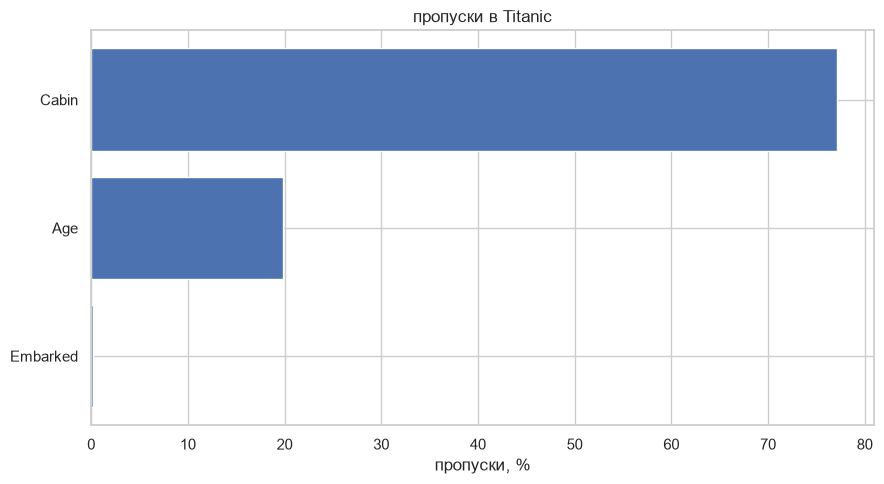

In [11]:
# анализ количества и доли пропусковв датасете
missing=pd.DataFrame({"пропуски":train_df.isnull().sum()})
missing["процент пропусков"]=(missing["пропуски"]/len(train_df)*100).round(2)
display(missing.sort_values("пропуски",ascending=False))

# визуализация доли пропусков
m=missing[missing["пропуски"]>0].sort_values("процент пропусков")
plt.figure(figsize=(9,5)); plt.barh(m.index,m["процент пропусков"]); plt.xlabel("пропуски, %"); plt.title("пропуски в Titanic"); plt.tight_layout(); plt.show()

In [12]:
# асимметрия и эксцесс числовых признаков
num=["Age","SibSp","Parch","Fare"]
display(pd.DataFrame({"Skewness":train_df[num].skew(),"Kurtosis":train_df[num].kurtosis()}))

# частота категорий
for col in ["Sex","Pclass","Embarked"]:
    print("\n",col); display(train_df[col].value_counts(dropna=False))

,Skewness,Kurtosis
Age,0.389108,0.178274
SibSp,3.695352,17.880420
Parch,2.749117,9.778125
Fare,4.787317,33.398141



 Sex


Sex
male      577
female    314
Name: count, dtype: int64


 Pclass


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


 Embarked


Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

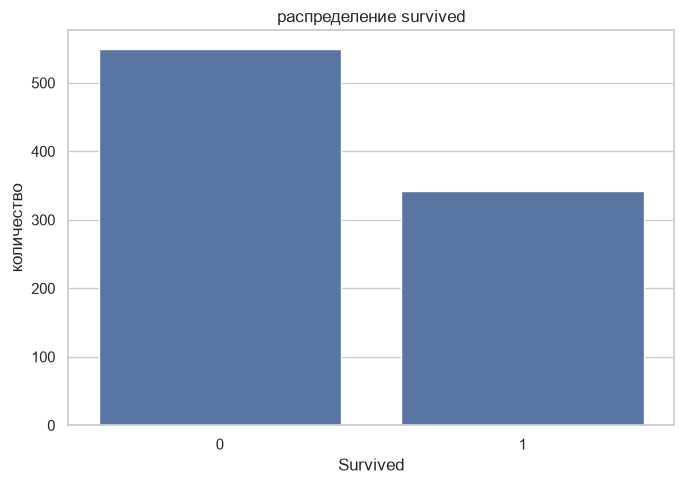

In [13]:
# распределение целевой переменной
plt.figure(figsize=(7,5)); ax=sns.countplot(data=train_df,x="Survived"); ax.set(xlabel="Survived",ylabel="количество",title="распределение survived"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"countplot_survived.png",dpi=150);plt.show()

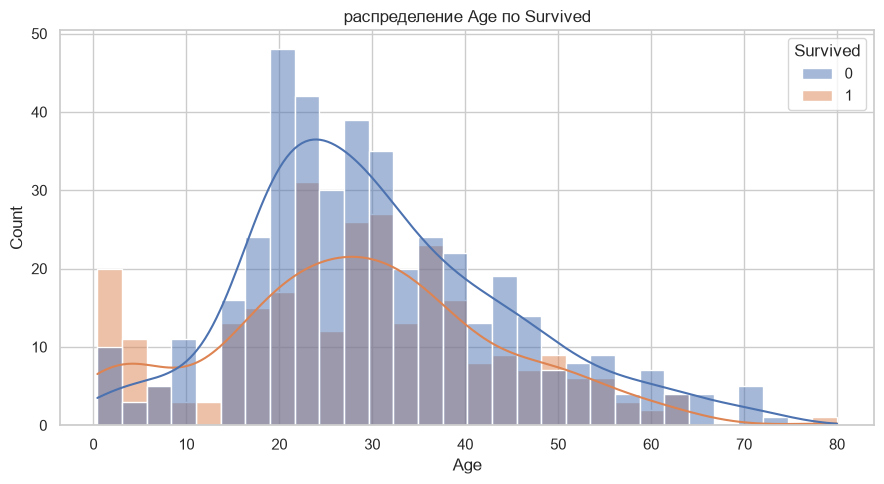

In [14]:
# возраст с разделением по выживанию
plt.figure(figsize=(9,5)); sns.histplot(data=train_df,x="Age",hue="Survived",kde=True,bins=30); plt.title("распределение Age по Survived"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"histplot_age_survived.png",dpi=150);plt.show()

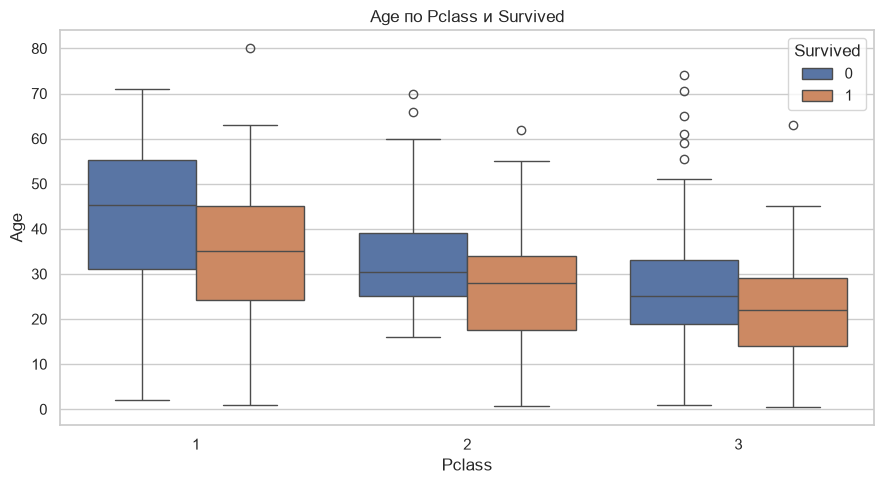

In [15]:
# возраст по классу и исходу
plt.figure(figsize=(9,5)); sns.boxplot(data=train_df,x="Pclass",y="Age",hue="Survived"); plt.title("Age по Pclass и Survived"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"boxplot_age_pclass_survived.png",dpi=150);plt.show()

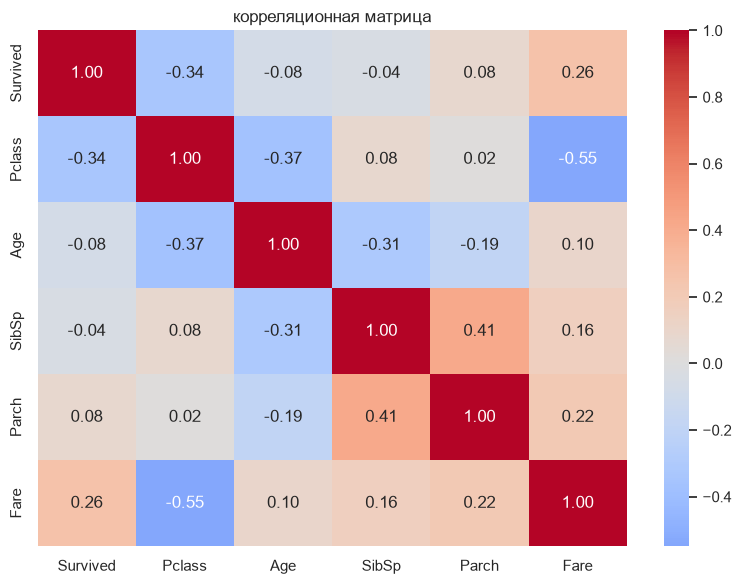

In [16]:
# корреляционная матрица числовых признаков
corr=train_df[["Survived","Pclass","Age","SibSp","Parch","Fare"]].corr()
plt.figure(figsize=(8,6)); sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0); plt.title("корреляционная матрица"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"heatmap_corr.png",dpi=150);plt.show()

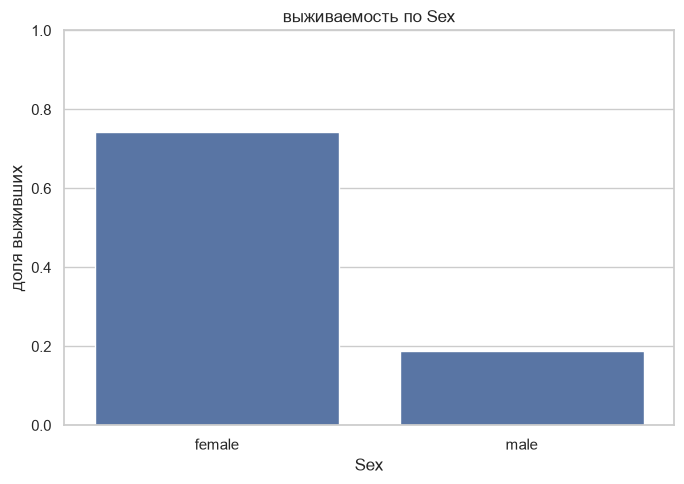

In [17]:
# выживаемость по полу
s=train_df.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(7,5)); sns.barplot(x=s.index,y=s.values); plt.ylim(0,1); plt.ylabel("доля выживших"); plt.title("выживаемость по Sex"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"barplot_sex.png",dpi=150);plt.show()

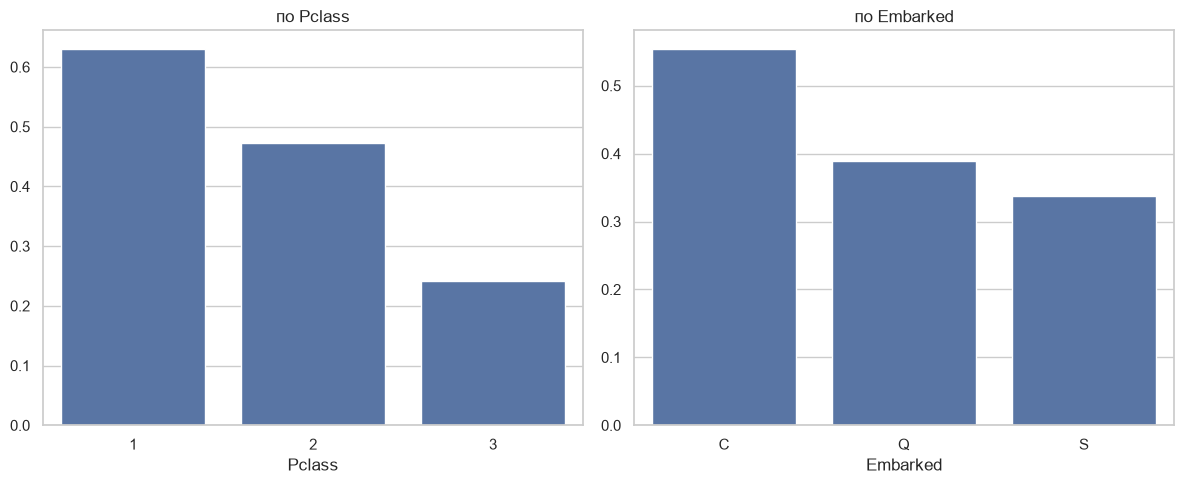

In [18]:
# выживаемость по классу и порту посадки
s1=train_df.groupby("Pclass")["Survived"].mean(); s2=train_df.groupby("Embarked")["Survived"].mean()
fig,ax=plt.subplots(1,2,figsize=(12,5)); sns.barplot(x=s1.index,y=s1.values,ax=ax[0]); sns.barplot(x=s2.index,y=s2.values,ax=ax[1]); ax[0].set_title("по Pclass"); ax[1].set_title("по Embarked"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"barplot_pclass_embarked.png",dpi=150);plt.show()

### Наблюдения по EDA
В `Survived` есть умеренный дисбаланс классов.
`Age`, `Cabin` и `Embarked` содержат пропуски.
Выживаемость заметно различается по полу и классу билета.
`Fare` и `Pclass` несут полезную информацию о положении пассажира.
 Для модели нужны обработанные числовые представления категорий.

In [19]:
# создание предобработки данных в копи датасета
df=train_df.copy()

In [20]:
# заполнение Age медианой внутри групп Pclass + Sex
df["Age"]=df.groupby(["Pclass","Sex"])["Age"].transform(lambda x:x.fillna(x.median()))
df["Age"]=df["Age"].fillna(df["Age"].median())
# заполнение Embarked модой 
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
# удаление Cabin
df=df.drop(columns=["Cabin"])

In [21]:
# feature engineering
df["Family_Size"]=df["SibSp"]+df["Parch"]+1
df["Is_Alone"]=(df["Family_Size"]==1).astype(int)
df["Age_Group"]=pd.cut(df["Age"],bins=[0,12,18,35,60,np.inf],labels=["Child","Teen","YoungAdult","Adult","Senior"])

In [22]:
# кодирование Sex и Embarked
le_sex=LabelEncoder(); df["Sex_Encoded"]=le_sex.fit_transform(df["Sex"])
df=pd.get_dummies(df,columns=["Embarked"],drop_first=True,dtype=int)
print("Оставшиеся пропуски:"); display(df.isnull().sum()[df.isnull().sum()>0])
display(df.head())

Оставшиеся пропуски:


Series([], dtype: int64)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Family_Size,Is_Alone,Age_Group,Sex_Encoded,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,2,0,YoungAdult,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,2,0,Adult,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,1,1,YoungAdult,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,2,0,YoungAdult,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,1,1,YoungAdult,1,0,1


### Обоснование обработки
`Age` заполняется групповой медианой, потому что возраст связан с классом и полом, а медиана устойчива к выбросам. `Embarked` заполняется модой, так как это категориальный признак. `Cabin` удаляется из-за большого количества пропусков. `Family_Size`, `Is_Alone` и `Age_Group` добавляют информацию о семейном положении и возрастной группе.

## Построение и обучение моделей

Используются две обязательные модели: Logistic Regression и Decision Tree. Logistic Regression масштабируется через `StandardScaler`; дереву решений масштабирование не требуется.

In [23]:
# выбор признаков из подготовленной таблицы
feature_cols=["Pclass","Sex_Encoded","Age","SibSp","Parch","Fare","Family_Size","Is_Alone","Embarked_Q","Embarked_S"]
X=df[feature_cols] 
y=df["Survived"]

# деление данных с сохранением пропорций классов
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# масштабирование признаков для Logistic Regression
scaler=StandardScaler(); X_train_scaled=scaler.fit_transform(X_train); X_test_scaled=scaler.transform(X_test)

# создание и обучение Logistic Regression с замером времени
lr_model=LogisticRegression(penalty="l2",C=1.0,max_iter=1000,random_state=42)
start=time.time(); lr_model.fit(X_train_scaled,y_train); lr_time=time.time()-start

# создание и обучение Decision Tree с ограничением глубины
dt_model=DecisionTreeClassifier(max_depth=5,min_samples_split=5,min_samples_leaf=2,random_state=42)
start=time.time(); dt_model.fit(X_train,y_train); dt_time=time.time()-start

print(f"время LR: {lr_time:.4f} сек."); print(f"время DT: {dt_time:.4f} сек.")

время LR: 0.0073 сек.
время DT: 0.0027 сек.


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | `penalty='l2', C=1.0` | ✅ Да | 0.0073 сек |
| Decision Tree | `max_depth=5` | ❌ Нет | 0.0027 сек |

**Почему эти модели:**

- LR — простая, интерпретируемая, даёт вероятности
- DT — нелинейная, устойчива к выбросам, показывает важность признаков

## Оценка качества

Для каждой модели рассчитываются Accuracy, Precision, Recall, F1 и ROC-AUC. Также строятся матрицы ошибок и ROC-кривые.

In [24]:
# классы и вероятности двух моделей
y_pred_lr=lr_model.predict(X_test_scaled); y_proba_lr=lr_model.predict_proba(X_test_scaled)[:,1]
y_pred_dt=dt_model.predict(X_test); y_proba_dt=dt_model.predict_proba(X_test)[:,1]

# подсчет метрик
def metrics(y_true,y_pred,y_proba):
    return [accuracy_score(y_true,y_pred),precision_score(y_true,y_pred),recall_score(y_true,y_pred),f1_score(y_true,y_pred),roc_auc_score(y_true,y_proba)]

# вывод метрик в DataFrame
metrics_df=pd.DataFrame([metrics(y_test,y_pred_lr,y_proba_lr),metrics(y_test,y_pred_dt,y_proba_dt)],index=["Logistic Regression","Decision Tree"],columns=["Accuracy","Precision","Recall","F1","ROC-AUC"])
display(metrics_df.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8486
Decision Tree,0.7821,0.7419,0.6667,0.7023,0.8132


In [25]:
# вывод подробных отчётов классификации.
print("Logistic Regression\n",classification_report(y_test,y_pred_lr,target_names=["Не выжил","Выжил"]))
print("Decision Tree\n",classification_report(y_test,y_pred_dt,target_names=["Не выжил","Выжил"]))

Logistic Regression
               precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Decision Tree
               precision    recall  f1-score   support

    Не выжил       0.80      0.85      0.83       110
       Выжил       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



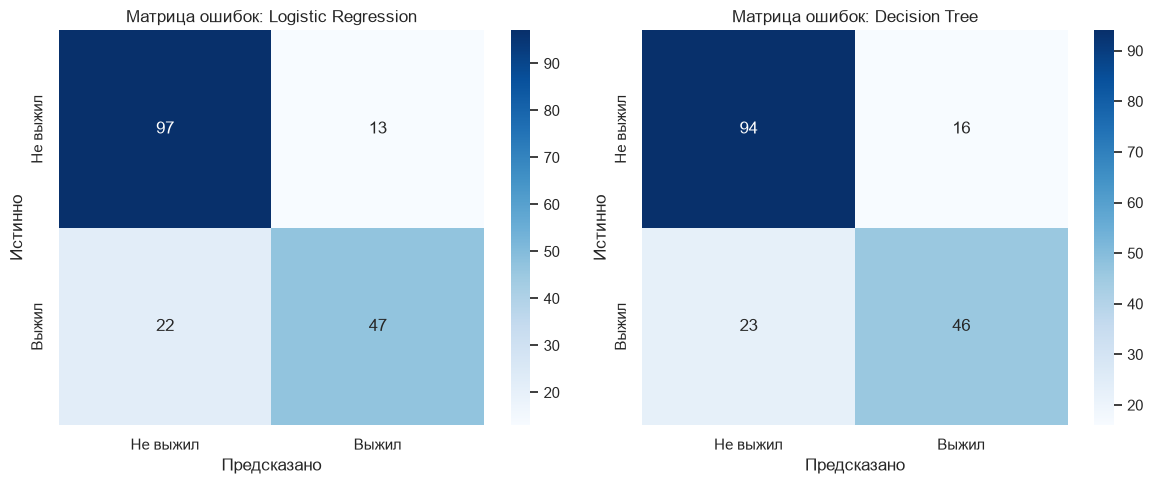

In [26]:
# построение матриц ошибок для каждой модели
fig,ax=plt.subplots(1,2,figsize=(12,5))
for a,p,t in [(ax[0],y_pred_lr,"Logistic Regression"),(ax[1],y_pred_dt,"Decision Tree")]:
    sns.heatmap(confusion_matrix(y_test,p),annot=True,fmt="d",cmap="Blues",xticklabels=["Не выжил","Выжил"],yticklabels=["Не выжил","Выжил"],ax=a)
    a.set_xlabel("Предсказано"); a.set_ylabel("Истинно"); a.set_title("Матрица ошибок: "+t)
plt.tight_layout(); plt.savefig(EXAMPLES_DIR/"confusion_matrices.png",dpi=150); plt.show()

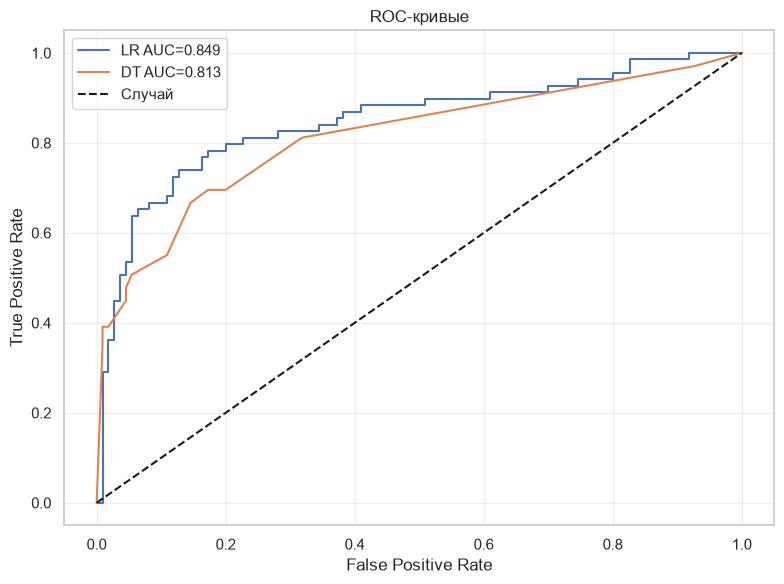

In [27]:
# построение ROC-кривых
fpr1,tpr1,_=roc_curve(y_test,y_proba_lr); fpr2,tpr2,_=roc_curve(y_test,y_proba_dt)
plt.figure(figsize=(8,6)); plt.plot(fpr1,tpr1,label=f"LR AUC={metrics_df.loc['Logistic Regression','ROC-AUC']:.3f}"); plt.plot(fpr2,tpr2,label=f"DT AUC={metrics_df.loc['Decision Tree','ROC-AUC']:.3f}"); plt.plot([0,1],[0,1],"k--",label="Случай")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC-кривые"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(EXAMPLES_DIR/"roc_curves.png",dpi=150); plt.show()

## Оценка качества

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | 0.8486 |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |

**Анализ:**

- Лучшая модель по ROC-AUC: **Logistic Regression** — ROC-AUC = **0.8486**.
- По Accuracy модель **Logistic Regression** показывает результат **0.8045**, что означает правильную классификацию примерно **80%** пассажиров тестовой выборки.
- По Precision модель **Logistic Regression** лучше определяет пассажиров, которым она предсказывает выживание: среди предсказанных как выжившие доля действительно выживших составляет **0.7833**.
- По Recall модель **Logistic Regression** лучше обнаруживает реально выживших пассажиров: она правильно находит **68%** пассажиров класса `Survived = 1`.
- Более высокий F1 у модели **Logistic Regression**, что говорит о более сбалансированном соотношении Precision и Recall.
- **Decision Tree** может сильнее переобучаться, поскольку дерево способно формировать сложные правила разбиения данных. В данной работе риск переобучения ограничен параметром `max_depth=5`.
- Если **Precision выше Recall**, модель более осторожна в предсказаниях «выживет»: она реже относит пассажира к выжившим без достаточных оснований, но при этом может пропускать часть реально выживших пассажиров.
- Если **Recall выше Precision**, модель чаще обнаруживает реально выживших пассажиров, но при этом чаще ошибочно относит к ним пассажиров, которые не выжили.
- ROC-AUC позволяет сравнить способность моделей различать классы независимо от одного фиксированного порога классификации.

## Интерпретация результатов

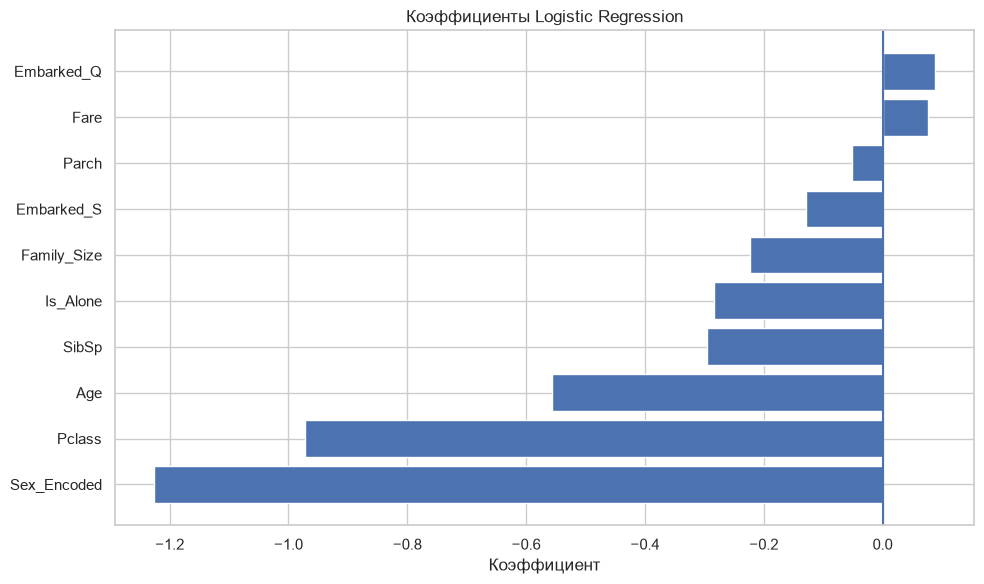

,Feature,Coefficient
8,Embarked_Q,0.0881
5,Fare,0.0772
4,Parch,-0.0512
9,Embarked_S,-0.1292
6,Family_Size,-0.2238
7,Is_Alone,-0.2837
3,SibSp,-0.2948
2,Age,-0.5572
0,Pclass,-0.9713
1,Sex_Encoded,-1.2259


In [28]:
# анализ коэффициентов Logistic Regression
coef=pd.DataFrame({"Feature":feature_cols,"Coefficient":lr_model.coef_[0]}).sort_values("Coefficient")
plt.figure(figsize=(10,6)); plt.barh(coef["Feature"],coef["Coefficient"]); plt.axvline(0); plt.xlabel("Коэффициент"); plt.title("Коэффициенты Logistic Regression"); plt.tight_layout(); plt.show()
display(coef.sort_values("Coefficient",ascending=False).round(4))

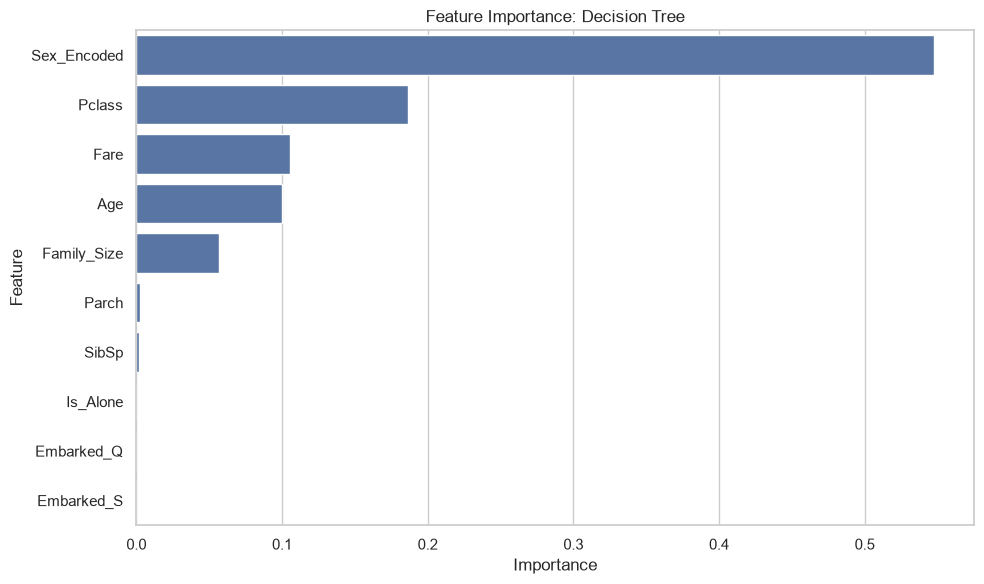

,Feature,Importance
1,Sex_Encoded,0.5477
0,Pclass,0.1862
5,Fare,0.1052
2,Age,0.0999
6,Family_Size,0.0566
4,Parch,0.0027
3,SibSp,0.0017
7,Is_Alone,0.0000
8,Embarked_Q,0.0000
9,Embarked_S,0.0000


Выживаемость по полу, %


Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Выживаемость по Pclass, %


Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

In [29]:
# анализ важности признаков Decision Tree
imp=pd.DataFrame({"Feature":feature_cols,"Importance":dt_model.feature_importances_}).sort_values("Importance",ascending=False)
plt.figure(figsize=(10,6)); sns.barplot(data=imp,x="Importance",y="Feature"); plt.title("Feature Importance: Decision Tree"); plt.tight_layout(); plt.show(); display(imp.round(4))

# фактическая выживаемость по полу и классу
print("Выживаемость по полу, %"); display((train_df.groupby("Sex")["Survived"].mean()*100).round(2))
print("Выживаемость по Pclass, %"); display((train_df.groupby("Pclass")["Survived"].mean()*100).round(2))

## Интерпретация
**Топ-3 признака, повышающих шанс выживания:**
-Embarked_Q — коэффициент +0.0881 (посадка в Куинстауне незначительно повышает шанс)
-Fare — коэффициент +0.0772 (более дорогой билет → выше шанс выживания)
-Parch — коэффициент −0.0512 (фактически понижающий, см. ниже)

**Топ-3 признака, понижающих шанс выживания:**
-Sex_Encoded — коэффициент −1.2259 (мужской пол резко снижает шанс; для женщин знак инвертируется)
-Pclass — коэффициент −0.9713 (чем выше номер класса, тем ниже выживаемость)
-Age — коэффициент −0.5572 (с возрастом шанс выживания падает)

**По важности признаков (Feature Importance):**
-Sex_Encoded — 0.5477 (доминирующий фактор, >50% вклада)
-Pclass — 0.1862
-Fare — 0.1052
-Age — 0.0999
-Family_Size — 0.0566

Остальные (Parch, SibSp, Is_Alone, Embarked_Q/S) — практически не влияют (<0.003)

**Бизнес-инсайты:**
-Женщины выживали в 74.2% случаев, мужчины — лишь в 18.9% — классический принцип «women and children first». Признак Sex_Encoded одновременно и самый важный, и самый сильный по коэффициенту.
-Пассажиры 1-го класса выживали в 63.0% случаев, 2-го — 47.3%, 3-го — всего 24.2%. Социально-экономический статус напрямую коррелировал с доступом к спасательным шлюпкам.
-Признак Fare действует в связке с Pclass: высокая цена билета → выше класс → выше выживаемость (коэффициент +0.0772).
-Is_Alone (−0.2837) и Family_Size (−0.2238) показывают, что одиночки и слишком большие семьи имели пониженный шанс — сказывалось отсутствие взаимопомощи либо сложности при эвакуации больших групп.
-Age (−0.5572) — дети и молодые пассажиры имели преимущество при посадке в шлюпки.
-Embarked_Q (+0.0881) — незначительный положительный эффект, вероятно, связан с тем, что среди пассажиров Куинстауна было больше женщин из 3-го класса, выживших вопреки общим ожиданиям.
-Embarked_S (−0.1292) — Саутгемптон, крупнейший порт посадки, даёт слабый отрицательный вклад (много мужчин 3-го класса).

## Функция предсказания

In [30]:
def predict_passenger(passenger_data,model,scaler,feature_cols,use_scaling=True):
    data=passenger_data.copy()
    # создание признаков семейного состава
    data["Family_Size"]=data["SibSp"]+data["Parch"]+1
    data["Is_Alone"]=int(data["Family_Size"]==1)
    # кодирование категорий
    data["Sex_Encoded"]=1 if data["Sex"]=="male" else 0
    data["Embarked_Q"]=int(data["Embarked"]=="Q"); data["Embarked_S"]=int(data["Embarked"]=="S")
    # формирование признаков строго в исходном порядке.
    X_new=pd.DataFrame([data])[feature_cols]
    if use_scaling: X_new=scaler.transform(X_new)
    prediction=int(model.predict(X_new)[0]); probability=float(model.predict_proba(X_new)[0,1])
    return prediction,probability

In [31]:
# проверка функции на пяти разных профилях пассажиров
examples=[
{"Pclass":1,"Sex":"female","Age":25,"SibSp":1,"Parch":0,"Fare":100,"Embarked":"C"},
{"Pclass":3,"Sex":"male","Age":30,"SibSp":0,"Parch":0,"Fare":7.25,"Embarked":"S"},
{"Pclass":2,"Sex":"female","Age":5,"SibSp":3,"Parch":1,"Fare":30,"Embarked":"S"},
{"Pclass":1,"Sex":"male","Age":60,"SibSp":0,"Parch":0,"Fare":200,"Embarked":"C"},
{"Pclass":3,"Sex":"female","Age":22,"SibSp":0,"Parch":0,"Fare":8,"Embarked":"Q"}]
rows=[]
for i,p in enumerate(examples,1):
    lr,plr=predict_passenger(p,lr_model,scaler,feature_cols,True)
    dt,pdt=predict_passenger(p,dt_model,scaler,feature_cols,False)
    rows.append({"Пример":i,"Pclass":p["Pclass"],"Sex":p["Sex"],"Age":p["Age"],"LR":lr,"LR %":plr,"DT":dt,"DT %":pdt,"Совпадают":lr==dt})
res=pd.DataFrame(rows); display(res.style.format({"LR %":"{:.1%}","DT %":"{:.1%}"}))

,Пример,Pclass,Sex,Age,LR,LR %,DT,DT %,Совпадают
0,1,1,female,25,1,96.1%,1,100.0%,True
1,2,3,male,30,0,7.6%,0,11.0%,True
2,3,2,female,5,1,80.8%,1,100.0%,True
3,4,1,male,60,0,30.6%,0,30.9%,True
4,5,3,female,22,1,73.5%,1,53.5%,True


## Сохранение модели

In [32]:
joblib.dump(lr_model,MODEL_DIR/"lr_model.pkl"); joblib.dump(dt_model,MODEL_DIR/"dt_model.pkl")
joblib.dump(scaler,MODEL_DIR/"scaler.pkl"); joblib.dump(le_sex,MODEL_DIR/"le_sex.pkl")

with open(MODEL_DIR/"feature_cols.json","w",encoding="utf-8") as f: json.dump(feature_cols,f,ensure_ascii=False,indent=2)
metrics_json={"logistic_regression":dict(zip(metrics_df.columns,metrics_df.loc["Logistic Regression"])),"decision_tree":dict(zip(metrics_df.columns,metrics_df.loc["Decision Tree"]))}
metrics_json["logistic_regression"]["training_time_sec"]=float(lr_time); metrics_json["decision_tree"]["training_time_sec"]=float(dt_time)
with open(MODEL_DIR/"metrics.json","w",encoding="utf-8") as f: json.dump(metrics_json,f,ensure_ascii=False,indent=2)
print("Файлы сохранены в models/")

Файлы сохранены в models/


## Выводы

### Что получилось
•	Достигнутая точность 0.8486
•	Лучшая модель и её метрики Logistic Regression	
Accuracy- 	0.8045	Precision - 0.7833	Recall - 0.6812	F1 - 0.7287 ROC-AUC - 0.8486
•	Время обучения 0.0073 сек
•	Ключевые инсайты из EDA 
В `Survived` есть умеренный дисбаланс классов.
`Age`, `Cabin` и `Embarked` содержат пропуски.
Выживаемость заметно различается по полу и классу билета.
`Fare` и `Pclass` несут полезную информацию о положении пассажира.


### Трудности
Основные проблемы — пропуски `Age`, `Cabin`, `Embarked`, дисбаланс классов и риск переобучения дерева.

### Улучшения
1. Извлечь `Title` из `Name`.
2. Добавить взаимодействия `Pclass × Sex`.
3. Проверить SMOTE.
4. Сравнить Random Forest и XGBoost/Gradient Boosting.
5. Использовать `GridSearchCV`.
6. Логарифмировать `Fare`.
7. Провести кросс-валидацию.
8. Объединить обработку и модель в `Pipeline`.

## Источники

1. Kaggle. *Titanic — Machine Learning from Disaster*. https://www.kaggle.com/c/titanic
2. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
3. McKinney, W. (2022). *Python for Data Analysis*. O'Reilly Media.
4. Scikit-learn Documentation. https://scikit-learn.org/stable/
5. Pandas Documentation. https://pandas.pydata.org/docs/
6. Matplotlib Documentation. https://matplotlib.org/stable/
7. Seaborn Documentation. https://seaborn.pydata.org/

## Приложение

# module-1-titanic/requirements.txt
```text
numpy==1.24.0
pandas==2.0.0
matplotlib==3.7.0
seaborn==0.12.0
scikit-learn==1.3.0
joblib==1.3.0
requests==2.31.0
```

In [ ]:
import time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
DATA_DIR=Path("data"); MODEL_DIR=Path("models"); EXAMPLES_DIR=Path("examples")
MODEL_DIR.mkdir(exist_ok=True); EXAMPLES_DIR.mkdir(exist_ok=True)
train_df=pd.read_csv("data/train.csv")
test_df=pd.read_csv("data/test.csv")
display(train_df.head())
print("train:", train_df.shape)
print("test:", test_df.shape)
train_df.info()
display(train_df.describe(include="all").T)
# анализ количества и доли пропусковв датасете
missing=pd.DataFrame({"пропуски":train_df.isnull().sum()})
missing["процент пропусков"]=(missing["пропуски"]/len(train_df)*100).round(2)
display(missing.sort_values("пропуски",ascending=False))

# визуализация доли пропусков
m=missing[missing["пропуски"]>0].sort_values("процент пропусков")
plt.figure(figsize=(9,5)); plt.barh(m.index,m["процент пропусков"]); plt.xlabel("пропуски, %"); plt.title("пропуски в Titanic"); plt.tight_layout(); plt.show()
# асимметрия и эксцесс числовых признаков
num=["Age","SibSp","Parch","Fare"]
display(pd.DataFrame({"Skewness":train_df[num].skew(),"Kurtosis":train_df[num].kurtosis()}))

# частота категорий
for col in ["Sex","Pclass","Embarked"]:
    print("\n",col); display(train_df[col].value_counts(dropna=False))
    # распределение целевой переменной
plt.figure(figsize=(7,5)); ax=sns.countplot(data=train_df,x="Survived"); ax.set(xlabel="Survived",ylabel="количество",title="распределение survived"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"countplot_survived.png",dpi=150);plt.show()
# возраст с разделением по выживанию
plt.figure(figsize=(9,5)); sns.histplot(data=train_df,x="Age",hue="Survived",kde=True,bins=30); plt.title("распределение Age по Survived"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"histplot_age_survived.png",dpi=150);plt.show()
# возраст по классу и исходу
plt.figure(figsize=(9,5)); sns.boxplot(data=train_df,x="Pclass",y="Age",hue="Survived"); plt.title("Age по Pclass и Survived"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"boxplot_age_pclass_survived.png",dpi=150);plt.show()
# корреляционная матрица числовых признаков
corr=train_df[["Survived","Pclass","Age","SibSp","Parch","Fare"]].corr()
plt.figure(figsize=(8,6)); sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0); plt.title("корреляционная матрица"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"heatmap_corr.png",dpi=150);plt.show()
# выживаемость по полу
s=train_df.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(7,5)); sns.barplot(x=s.index,y=s.values); plt.ylim(0,1); plt.ylabel("доля выживших"); plt.title("выживаемость по Sex"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"barplot_sex.png",dpi=150);plt.show()
# выживаемость по классу и порту посадки
s1=train_df.groupby("Pclass")["Survived"].mean(); s2=train_df.groupby("Embarked")["Survived"].mean()
fig,ax=plt.subplots(1,2,figsize=(12,5)); sns.barplot(x=s1.index,y=s1.values,ax=ax[0]); sns.barplot(x=s2.index,y=s2.values,ax=ax[1]); ax[0].set_title("по Pclass"); ax[1].set_title("по Embarked"); plt.tight_layout();  plt.savefig(EXAMPLES_DIR/"barplot_pclass_embarked.png",dpi=150);plt.show()

# создание предобработки данных в копи датасета
df=train_df.copy()
# заполнение Age медианой внутри групп Pclass + Sex
df["Age"]=df.groupby(["Pclass","Sex"])["Age"].transform(lambda x:x.fillna(x.median()))
df["Age"]=df["Age"].fillna(df["Age"].median())
# заполнение Embarked модой 
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
# удаление Cabin
df=df.drop(columns=["Cabin"])
# feature engineering
df["Family_Size"]=df["SibSp"]+df["Parch"]+1
df["Is_Alone"]=(df["Family_Size"]==1).astype(int)
df["Age_Group"]=pd.cut(df["Age"],bins=[0,12,18,35,60,np.inf],labels=["Child","Teen","YoungAdult","Adult","Senior"])
# кодирование Sex и Embarked
le_sex=LabelEncoder(); df["Sex_Encoded"]=le_sex.fit_transform(df["Sex"])
df=pd.get_dummies(df,columns=["Embarked"],drop_first=True,dtype=int)
print("Оставшиеся пропуски:"); display(df.isnull().sum()[df.isnull().sum()>0])
display(df.head())
# выбор признаков из подготовленной таблицы
feature_cols=["Pclass","Sex_Encoded","Age","SibSp","Parch","Fare","Family_Size","Is_Alone","Embarked_Q","Embarked_S"]
X=df[feature_cols] 
y=df["Survived"]

# деление данных с сохранением пропорций классов
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# масштабирование признаков для Logistic Regression
scaler=StandardScaler(); X_train_scaled=scaler.fit_transform(X_train); X_test_scaled=scaler.transform(X_test)

# создание и обучение Logistic Regression с замером времени
lr_model=LogisticRegression(penalty="l2",C=1.0,max_iter=1000,random_state=42)
start=time.time(); lr_model.fit(X_train_scaled,y_train); lr_time=time.time()-start

# создание и обучение Decision Tree с ограничением глубины
dt_model=DecisionTreeClassifier(max_depth=5,min_samples_split=5,min_samples_leaf=2,random_state=42)
start=time.time(); dt_model.fit(X_train,y_train); dt_time=time.time()-start

print(f"время LR: {lr_time:.4f} сек."); print(f"время DT: {dt_time:.4f} сек.")
# классы и вероятности двух моделей
y_pred_lr=lr_model.predict(X_test_scaled); y_proba_lr=lr_model.predict_proba(X_test_scaled)[:,1]
y_pred_dt=dt_model.predict(X_test); y_proba_dt=dt_model.predict_proba(X_test)[:,1]

# подсчет метрик
def metrics(y_true,y_pred,y_proba):
    return [accuracy_score(y_true,y_pred),precision_score(y_true,y_pred),recall_score(y_true,y_pred),f1_score(y_true,y_pred),roc_auc_score(y_true,y_proba)]

# вывод метрик в DataFrame
metrics_df=pd.DataFrame([metrics(y_test,y_pred_lr,y_proba_lr),metrics(y_test,y_pred_dt,y_proba_dt)],index=["Logistic Regression","Decision Tree"],columns=["Accuracy","Precision","Recall","F1","ROC-AUC"])
display(metrics_df.round(4))
# вывод подробных отчётов классификации.
print("Logistic Regression\n",classification_report(y_test,y_pred_lr,target_names=["Не выжил","Выжил"]))
print("Decision Tree\n",classification_report(y_test,y_pred_dt,target_names=["Не выжил","Выжил"]))
# построение матриц ошибок для каждой модели
fig,ax=plt.subplots(1,2,figsize=(12,5))
for a,p,t in [(ax[0],y_pred_lr,"Logistic Regression"),(ax[1],y_pred_dt,"Decision Tree")]:
    sns.heatmap(confusion_matrix(y_test,p),annot=True,fmt="d",cmap="Blues",xticklabels=["Не выжил","Выжил"],yticklabels=["Не выжил","Выжил"],ax=a)
    a.set_xlabel("Предсказано"); a.set_ylabel("Истинно"); a.set_title("Матрица ошибок: "+t)
plt.tight_layout(); plt.savefig(EXAMPLES_DIR/"confusion_matrices.png",dpi=150); plt.show()
# построение ROC-кривых
fpr1,tpr1,_=roc_curve(y_test,y_proba_lr); fpr2,tpr2,_=roc_curve(y_test,y_proba_dt)
plt.figure(figsize=(8,6)); plt.plot(fpr1,tpr1,label=f"LR AUC={metrics_df.loc['Logistic Regression','ROC-AUC']:.3f}"); plt.plot(fpr2,tpr2,label=f"DT AUC={metrics_df.loc['Decision Tree','ROC-AUC']:.3f}"); plt.plot([0,1],[0,1],"k--",label="Случай")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC-кривые"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.savefig(EXAMPLES_DIR/"roc_curves.png",dpi=150); plt.show()
# анализ коэффициентов Logistic Regression
coef=pd.DataFrame({"Feature":feature_cols,"Coefficient":lr_model.coef_[0]}).sort_values("Coefficient")
plt.figure(figsize=(10,6)); plt.barh(coef["Feature"],coef["Coefficient"]); plt.axvline(0); plt.xlabel("Коэффициент"); plt.title("Коэффициенты Logistic Regression"); plt.tight_layout(); plt.show()
display(coef.sort_values("Coefficient",ascending=False).round(4))
# анализ важности признаков Decision Tree
imp=pd.DataFrame({"Feature":feature_cols,"Importance":dt_model.feature_importances_}).sort_values("Importance",ascending=False)
plt.figure(figsize=(10,6)); sns.barplot(data=imp,x="Importance",y="Feature"); plt.title("Feature Importance: Decision Tree"); plt.tight_layout(); plt.show(); display(imp.round(4))

# фактическая выживаемость по полу и классу
print("Выживаемость по полу, %"); display((train_df.groupby("Sex")["Survived"].mean()*100).round(2))
print("Выживаемость по Pclass, %"); display((train_df.groupby("Pclass")["Survived"].mean()*100).round(2))
def predict_passenger(passenger_data,model,scaler,feature_cols,use_scaling=True):
    data=passenger_data.copy()
    # создание признаков семейного состава
    data["Family_Size"]=data["SibSp"]+data["Parch"]+1
    data["Is_Alone"]=int(data["Family_Size"]==1)
    # кодирование категорий
    data["Sex_Encoded"]=1 if data["Sex"]=="male" else 0
    data["Embarked_Q"]=int(data["Embarked"]=="Q"); data["Embarked_S"]=int(data["Embarked"]=="S")
    # формирование признаков строго в исходном порядке.
    X_new=pd.DataFrame([data])[feature_cols]
    if use_scaling: X_new=scaler.transform(X_new)
    prediction=int(model.predict(X_new)[0]); probability=float(model.predict_proba(X_new)[0,1])
    return prediction,probability
# проверка функции на пяти разных профилях пассажиров
examples=[
{"Pclass":1,"Sex":"female","Age":25,"SibSp":1,"Parch":0,"Fare":100,"Embarked":"C"},
{"Pclass":3,"Sex":"male","Age":30,"SibSp":0,"Parch":0,"Fare":7.25,"Embarked":"S"},
{"Pclass":2,"Sex":"female","Age":5,"SibSp":3,"Parch":1,"Fare":30,"Embarked":"S"},
{"Pclass":1,"Sex":"male","Age":60,"SibSp":0,"Parch":0,"Fare":200,"Embarked":"C"},
{"Pclass":3,"Sex":"female","Age":22,"SibSp":0,"Parch":0,"Fare":8,"Embarked":"Q"}]
rows=[]
for i,p in enumerate(examples,1):
    lr,plr=predict_passenger(p,lr_model,scaler,feature_cols,True)
    dt,pdt=predict_passenger(p,dt_model,scaler,feature_cols,False)
    rows.append({"Пример":i,"Pclass":p["Pclass"],"Sex":p["Sex"],"Age":p["Age"],"LR":lr,"LR %":plr,"DT":dt,"DT %":pdt,"Совпадают":lr==dt})
res=pd.DataFrame(rows); display(res.style.format({"LR %":"{:.1%}","DT %":"{:.1%}"}))
joblib.dump(lr_model,MODEL_DIR/"lr_model.pkl"); joblib.dump(dt_model,MODEL_DIR/"dt_model.pkl")
joblib.dump(scaler,MODEL_DIR/"scaler.pkl"); joblib.dump(le_sex,MODEL_DIR/"le_sex.pkl")

with open(MODEL_DIR/"feature_cols.json","w",encoding="utf-8") as f: json.dump(feature_cols,f,ensure_ascii=False,indent=2)
metrics_json={"logistic_regression":dict(zip(metrics_df.columns,metrics_df.loc["Logistic Regression"])),"decision_tree":dict(zip(metrics_df.columns,metrics_df.loc["Decision Tree"]))}
metrics_json["logistic_regression"]["training_time_sec"]=float(lr_time); metrics_json["decision_tree"]["training_time_sec"]=float(dt_time)
with open(MODEL_DIR/"metrics.json","w",encoding="utf-8") as f: json.dump(metrics_json,f,ensure_ascii=False,indent=2)
print("Файлы сохранены в models/")